# CatBoost Model Evaluation

This notebook evaluates the selected **global CatBoost demand-forecasting model** after model comparison and hyperparameter tuning.

The goals are to:

1. inspect validation performance overall and by dish;
2. compare CatBoost against the seasonal `T7` baseline;
3. understand the largest forecasting errors and any systematic bias;
4. assess prediction calibration;
5. inspect feature importance using both CatBoost's built-in importance and validation permutation importance;
6. test how much the model depends on literal dish identity;
7. measure the incremental value of historical, calendar, and weather feature groups.

### Evaluation discipline

All diagnostic and ablation decisions in this notebook use the **validation split only**. The held-out test results are not used to choose features or modify the model.

The main metrics are:

- **MAE**: average absolute error in units sold;
- **RMSE**: penalizes larger misses more strongly;
- **WAPE**: absolute error relative to total observed demand, useful when dishes operate at different demand scales.


## 1. Setup and load experiment artifacts

The official experiment is generated by `ml/model_comparison.py`. Rather than rebuilding preprocessing manually in this notebook, the notebook reuses the same helper functions and saved artifacts so that evaluation is consistent with training.


In [15]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ml.model_comparison import (
    load_dish_days,
    make_model,
    split_by_date,
)

ARTIFACT_DIR = Path("../artifacts/model_comparison")

metrics = pd.read_csv(ARTIFACT_DIR / "metrics.csv")
predictions = pd.read_csv(ARTIFACT_DIR / "predictions.csv")
predictions["DEMAND_DATE"] = pd.to_datetime(predictions["DEMAND_DATE"])

with open(ARTIFACT_DIR / "run.json", "r") as file:
    run_metadata = json.load(file)

# Rebuild exactly the same dish-day table and chronological split used by training.
_, long_df = load_dish_days()
splits = split_by_date(long_df)

train_df = splits["train"]
validation_df = splits["validation"]

numeric_features = [
    column
    for column in long_df.columns
    if column not in ("DEMAND_DATE", "DISH", "DEMAND")
]

catboost_params = run_metadata["selected_parameters"]["CatBoost"]

def regression_metrics(actual, predicted):
    """Return the three evaluation metrics used throughout this notebook."""
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "WAPE_pct": float(
            np.abs(actual - predicted).sum()
            / np.abs(actual).sum()
            * 100
        ),
    }

catboost_params


{'depth': 8, 'iterations': 500, 'l2_leaf_reg': 10, 'learning_rate': 0.05}

## 2. Model Selection

Ridge Regression, Random Forest, XGBoost, and CatBoost were compared using the same chronological train/validation/test split.

CatBoost was selected as the final forecasting model because it achieved the lowest validation error among the candidate models:


| Model | Validation MAE | RMSE | WAPE |
|---|---:|---:|---:|
| Ridge | 4.951 | 7.058 | 27.98% |
| Random Forest | 4.839 | 7.019 | 27.35% |
| XGBoost | 4.827 | 6.945 | 27.28% |
| **CatBoost** | **4.687** | **6.857** | **26.49%** |

CatBoost was therefore selected based on validation performance, with MAE used as the primary model-selection metric.

## 3. Validation performance

### 3.1 Overall and per-dish CatBoost performance

The global CatBoost model is trained across all dishes, but its predictions are evaluated separately for each dish to ensure that the overall score is not hiding poor performance on individual menu items.


In [16]:
catboost_validation = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "CatBoost")
][
    [
        "dish",
        "MAE",
        "RMSE",
        "WAPE_pct",
        "negative_predictions",
    ]
]

catboost_validation


,dish,MAE,RMSE,WAPE_pct,negative_predictions
40,ALL,4.687332,6.856607,26.489878,0
41,CALAMARI,1.994365,2.434751,52.609136,0
42,FISH,1.859281,2.466095,43.701058,0
43,PRAWNS,3.562502,4.372183,30.687176,0
44,CHICKEN,6.805492,10.320231,22.226963,0
45,KOFTA,5.249353,6.395817,29.949630,0
46,LAMB,8.058708,10.274434,22.770560,0
47,STEAK,5.281625,6.707323,25.548757,0


### Result

Overall validation performance is approximately **MAE 4.687**, **RMSE 6.857**, and **WAPE 26.49%**, with **no negative predictions**.

Absolute error is naturally lower for low-volume dishes such as Calamari and Fish, while their WAPE is higher because a small unit error represents a larger fraction of their typical demand. Higher-volume dishes such as Chicken and Lamb have larger MAE in raw units but substantially lower relative error.


### 3.2 CatBoost versus the seasonal `T7` baseline

A useful forecasting model should improve on a simple rule such as using demand from seven recorded observations earlier. This comparison checks whether CatBoost's overall improvement is also present for every individual dish.


In [17]:
seasonal = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "Seasonal T7")
    & (metrics["dish"] != "ALL")
][["dish", "MAE", "RMSE", "WAPE_pct"]].rename(
    columns={
        "MAE": "Seasonal_MAE",
        "RMSE": "Seasonal_RMSE",
        "WAPE_pct": "Seasonal_WAPE_pct",
    }
)

catboost = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "CatBoost")
    & (metrics["dish"] != "ALL")
][["dish", "MAE", "RMSE", "WAPE_pct"]].rename(
    columns={
        "MAE": "CatBoost_MAE",
        "RMSE": "CatBoost_RMSE",
        "WAPE_pct": "CatBoost_WAPE_pct",
    }
)

per_dish_comparison = seasonal.merge(catboost, on="dish")

per_dish_comparison["MAE_improvement_pct"] = (
    (
        per_dish_comparison["Seasonal_MAE"]
        - per_dish_comparison["CatBoost_MAE"]
    )
    / per_dish_comparison["Seasonal_MAE"]
    * 100
)

per_dish_comparison[
    [
        "dish",
        "Seasonal_MAE",
        "CatBoost_MAE",
        "MAE_improvement_pct",
        "Seasonal_RMSE",
        "CatBoost_RMSE",
        "Seasonal_WAPE_pct",
        "CatBoost_WAPE_pct",
    ]
]


,dish,Seasonal_MAE,CatBoost_MAE,MAE_improvement_pct,Seasonal_RMSE,CatBoost_RMSE,Seasonal_WAPE_pct,CatBoost_WAPE_pct
0,CALAMARI,2.336364,1.994365,14.638094,3.076302,2.434751,61.630695,52.609136
1,FISH,2.290909,1.859281,18.840892,3.216435,2.466095,53.846154,43.701058
2,PRAWNS,5.000000,3.562502,28.749957,5.929893,4.372183,43.069695,30.687176
3,CHICKEN,10.427273,6.805492,34.733730,15.556641,10.320231,34.055819,22.226963
4,KOFTA,6.900000,5.249353,23.922415,9.068928,6.395817,39.367220,29.949630
5,LAMB,10.200000,8.058708,20.993058,12.405277,10.274434,28.820961,22.770560
6,STEAK,7.400000,5.281625,28.626691,9.897658,6.707323,35.795954,25.548757


### Result

CatBoost outperforms the seasonal `T7` baseline on **all seven dishes** across MAE, RMSE, and WAPE. Shows that the global improvement is not being produced only by one or two high-volume dishes.


## 4. Error analysis

Check when model fails.

- positive error → the model underpredicted
- negative error → the model overpredicted


In [18]:
cat_val = predictions[
    predictions["split"] == "validation"
].copy()

cat_val["ERROR"] = cat_val["DEMAND"] - cat_val["CatBoost"]
cat_val["ABS_ERROR"] = cat_val["ERROR"].abs()

context_features = [
    "DEMAND_T1",
    "DEMAND_T7",
    "MEAN_SAME_WDAY_W4",
    "WEEKEND",
    "ISHOLIDAY",
    "PRECIPITATION",
    "AIR_TEMPERATURE",
]

cat_val_context = cat_val.merge(
    long_df[
        [
            "DEMAND_DATE",
            "DISH",
            *context_features,
        ]
    ],
    on=["DEMAND_DATE", "DISH"],
    how="left",
    validate="one_to_one",
)

worst_context = (
    cat_val_context
    .sort_values("ABS_ERROR", ascending=False)
    .head(20)
)

worst_context[
    [
        "DEMAND_DATE",
        "DISH",
        "DEMAND",
        "CatBoost",
        "ERROR",
        "ABS_ERROR",
        *context_features,
    ]
]


,DEMAND_DATE,DISH,DEMAND,CatBoost,ERROR,ABS_ERROR,DEMAND_T1,DEMAND_T7,MEAN_SAME_WDAY_W4,WEEKEND,ISHOLIDAY,PRECIPITATION,AIR_TEMPERATURE
406,2015-06-17,CHICKEN,93,26.347376,66.652624,66.652624,31,21,25.75,0,0,0.0,18.750000
614,2015-06-05,LAMB,70,34.001103,35.998897,35.998897,40,56,50.75,0,0,0.0,29.958333
385,2015-05-27,CHICKEN,3,29.925099,-26.925099,26.925099,33,31,30.00,0,0,0.0,12.858333
610,2015-06-01,LAMB,53,28.150516,24.849484,24.849484,17,30,25.75,0,0,0.0,16.733333
392,2015-06-03,CHICKEN,48,23.830194,24.169806,24.169806,37,3,20.75,0,0,0.0,23.641667
593,2015-05-15,LAMB,61,37.320078,23.679922,23.679922,27,44,46.75,0,0,0.5,13.508333
628,2015-06-19,LAMB,62,39.284390,22.715610,22.715610,43,37,51.25,0,0,0.0,14.300000
710,2015-05-22,STEAK,1,23.609028,-22.609028,22.609028,18,27,27.50,0,0,0.0,16.725000
607,2015-05-29,LAMB,56,33.483083,22.516917,22.516917,38,42,46.00,0,0,0.7,17.566667
647,2015-07-08,LAMB,49,27.986446,21.013554,21.013554,31,29,36.50,0,0,0.0,20.633333


### Result: largest misses

The largest errors are dominated by unexpected demand shocks.

Examples from validation include:

- Chicken on 2015-06-17: actual demand 93 while recent historical signals were around 21–31 units, so the prediction near 26 was consistent with the available history.
- Chicken on 2015-05-27: actual demand fell to 3 even though `T1`, `T7`, and same-weekday history were all around 30.
- Steak on 2015-05-22: actual demand fell to 1 despite recent historical values around the mid-20s.

These cases suggest that many of the largest misses are caused by sudden spikes or drops that are not supported by the available historical features. Can possibly be improved by richer external context in our own model, things such as promotions, events, closures, ect.


### 4.1 Bias by dish

Mean signed residual checks whether CatBoost systematically predicts too high or too low for particular dishes.


In [19]:
dish_error = (
    cat_val
    .groupby("DISH")
    .agg(
        mean_error=("ERROR", "mean"),
        mean_absolute_error=("ABS_ERROR", "mean"),
        actual_mean=("DEMAND", "mean"),
        predicted_mean=("CatBoost", "mean"),
    )
    .reset_index()
)

dish_error


,DISH,mean_error,mean_absolute_error,actual_mean,predicted_mean
0,CALAMARI,-0.741074,1.994365,3.790909,4.531983
1,CHICKEN,0.781402,6.805492,30.618182,29.836780
2,FISH,-0.390614,1.859281,4.254545,4.645160
3,KOFTA,-1.511384,5.249353,17.527273,19.038657
4,LAMB,3.677081,8.058708,35.390909,31.713828
5,PRAWNS,0.514494,3.562502,11.609091,11.094597
6,STEAK,-0.658420,5.281625,20.672727,21.331147


### Result

Most dish-level biases are relatively small, but **Lamb stands out with a mean error of about +3.68 units**, meaning it is systematically underpredicted over the validation period.

This is worth monitoring, but it is not a reason to hard-code a Lamb-specific correction. In the eventual SME system, this type of pattern should be handled generically through learned per-`dish_id` calibration based on local residual history.


### 4.2 Calibration by predicted demand level

Grouping observations by actual demand can mechanically create an apparent regression-to-the-mean pattern. A cleaner calibration check groups observations by model predictions, then compares average predicted and observed demand within each prediction band.


In [20]:
cat_val["PREDICTED_LEVEL"] = pd.qcut(
    cat_val["CatBoost"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High",
    ],
    duplicates="drop",
)

prediction_calibration = (
    cat_val
    .groupby("PREDICTED_LEVEL", observed=True)
    .agg(
        mean_actual=("DEMAND", "mean"),
        mean_prediction=("CatBoost", "mean"),
        mean_error=("ERROR", "mean"),
        mean_absolute_error=("ABS_ERROR", "mean"),
    )
    .reset_index()
)

prediction_calibration


,PREDICTED_LEVEL,mean_actual,mean_prediction,mean_error,mean_absolute_error
0,Low,3.694301,4.175075,-0.480774,1.742864
1,Medium-Low,11.531250,11.413090,0.118160,3.832668
2,Medium-High,20.807292,20.821312,-0.014020,5.420846
3,High,34.730570,33.400735,1.329835,7.752323


### Result

CatBoost is **reasonably calibrated across predicted demand levels**:

- low predicted demand is slightly overpredicted;
- medium-low and medium-high bands are close to unbiased;
- the highest predicted-demand band is underpredicted by only about **1.33 units on average**.

This suggests that the extreme errors observed earlier are primarily unusual demand shocks rather than a broad tendency for CatBoost to suppress all high-demand predictions.


## 5. Reconstruct the selected CatBoost model

The saved experiment metadata contains the hyperparameters selected by training-only time-series cross-validation. The model is reconstructed on the **original training split only** for feature analysis and ablation experiments.


In [21]:
X_train = train_df[["DISH", *numeric_features]].copy()
y_train = train_df["DEMAND"].copy()

X_val = validation_df[["DISH", *numeric_features]].copy()
y_val = validation_df["DEMAND"].copy()

catboost_model = make_model(
    "CatBoost",
    numeric_features,
    catboost_params,
)

catboost_model.fit(X_train, y_train)

baseline_predictions = catboost_model.predict(X_val)
baseline_metrics = regression_metrics(y_val, baseline_predictions)

pd.DataFrame(
    [{"model": "Selected CatBoost", **baseline_metrics}]
)


,model,MAE,RMSE,WAPE_pct
0,Selected CatBoost,4.687332,6.856607,26.489878


The reconstructed model reproduces the official validation result (approximately **MAE 4.687**), confirming that the notebook is analysing the same selected model configuration.


## 6. Feature importance

Two complementary importance methods are used:

1. **CatBoost built-in feature importance** describes how strongly the fitted model used each feature internally.
2. **Validation permutation importance** measures how much validation MAE worsens when a feature's information is destroyed.

Neither measure implies causality, and correlated features can share or substitute for one another.


### 6.1 CatBoost built-in feature importance


In [22]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.get_feature_importance(),
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)


,feature,importance
0,MEAN_SAME_WDAY_W3,10.478374
1,MEAN_SAME_WDAY_W4,10.219122
2,SATURDAY,8.940838
3,CUM_DEMAND_T6,6.543294
4,AIR_TEMPERATURE,5.247757
5,CUM_DEMAND_T7,4.842554
6,MEAN_SAME_WDAY_W2,4.170387
7,WEEKEND,4.078434
8,CUM_DEMAND_T5,3.639105
9,DEMAND_T6,3.500760


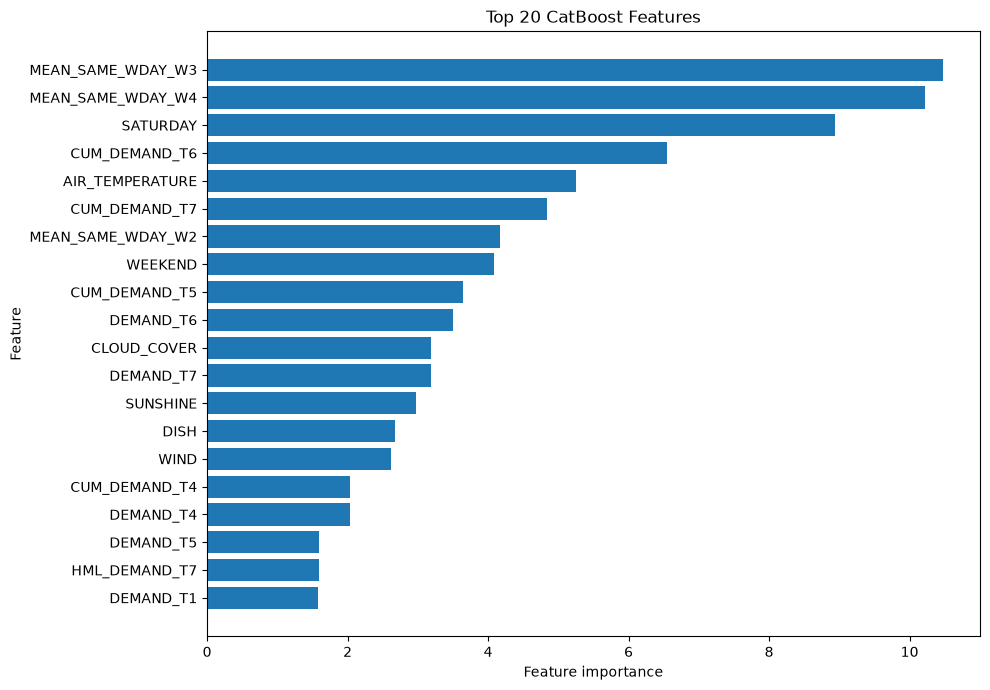

In [23]:
top_features = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Features")
plt.tight_layout()
plt.show()


### Result

The corrected CatBoost model relies most heavily on recent same-weekday demand patterns. `MEAN_SAME_WDAY_W3` and `MEAN_SAME_WDAY_W4` are the two most important features, with importance scores of 10.48 and 10.22 respectively. This indicates that demand on the same weekday over the previous several weeks provides substantial predictive information.

Calendar effects are also important. `SATURDAY` is the third most important feature (8.94), while `WEEKEND` also appears among the top features (4.08), suggesting that demand patterns differ meaningfully between weekdays and weekends.

Several cumulative and lagged demand features are influential, including `CUM_DEMAND_T6`, `CUM_DEMAND_T7`, `DEMAND_T6`, and `DEMAND_T7`. This indicates that the model combines both recent demand history and longer short-term demand patterns when producing forecasts.

Weather variables also contribute to the model. `AIR_TEMPERATURE` has an importance of 5.25, while `CLOUD_COVER`, `SUNSHINE`, and `WIND` also appear among the top 20 features. However, feature importance alone does not establish that these variables causally affect demand.

`DISH` has an importance of 2.68. This suggests that dish identity contributes additional information, although the model relies more heavily on historical demand, calendar patterns, and weather conditions.

Overall, the importance ranking suggests that the model primarily learns from historical demand patterns, particularly same-weekday behavior, while calendar and weather information provide additional predictive context.

### 6.2 Validation permutation importance

For each feature, its validation values are shuffled while all other features remain unchanged. The increase in MAE measures how much predictive performance is lost when that feature's information is destroyed.

Each feature is shuffled 10 times to reduce sensitivity to a single random permutation.


In [24]:
rng = np.random.default_rng(42)
n_repeats = 10
permutation_results = []

for feature in X_val.columns:
    mae_increases = []

    for _ in range(n_repeats):
        X_permuted = X_val.copy()
        X_permuted[feature] = rng.permutation(
            X_permuted[feature].to_numpy()
        )

        permuted_predictions = catboost_model.predict(
            X_permuted
        )

        permuted_mae = mean_absolute_error(
            y_val,
            permuted_predictions,
        )

        mae_increases.append(
            permuted_mae - baseline_metrics["MAE"]
        )

    permutation_results.append({
        "feature": feature,
        "mae_increase_mean": np.mean(mae_increases),
        "mae_increase_std": np.std(mae_increases),
    })

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .sort_values("mae_increase_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df.head(20)


,feature,mae_increase_mean,mae_increase_std
0,MEAN_SAME_WDAY_W4,1.165661,0.094412
1,MEAN_SAME_WDAY_W3,0.991140,0.057643
2,CUM_DEMAND_T6,0.638998,0.087551
3,CUM_DEMAND_T7,0.546788,0.048715
4,DISH,0.377954,0.039464
5,MEAN_SAME_WDAY_W2,0.333558,0.025260
6,DEMAND_T6,0.271535,0.038915
7,CUM_DEMAND_T5,0.271126,0.030716
8,CUM_DEMAND_T4,0.187033,0.015203
9,SATURDAY,0.114966,0.052163


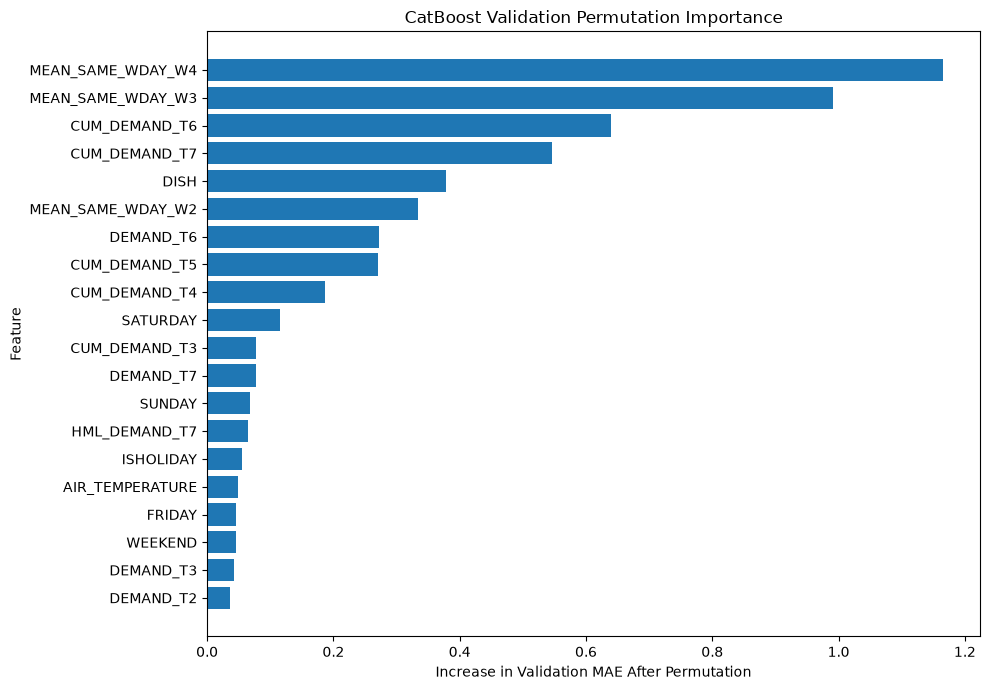

In [25]:
top_permutation = (
    permutation_importance_df
    .head(20)
    .sort_values("mae_increase_mean")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_permutation["feature"],
    top_permutation["mae_increase_mean"],
)

plt.xlabel("Increase in Validation MAE After Permutation")
plt.ylabel("Feature")
plt.title("CatBoost Validation Permutation Importance")
plt.tight_layout()
plt.show()


### Result

Validation permutation importance provides stronger evidence that the model relies primarily on **historical demand behaviour**:

The strongest features were the same-weekday historical demand features. Shuffling `MEAN_SAME_WDAY_W4` increased validation MAE by approximately 1.17, while shuffling `MEAN_SAME_WDAY_W3` increased MAE by approximately 0.99. This suggests that recent demand from the same weekday across previous weeks is particularly important for forecasting.

Longer short-term demand history was also influential. `CUM_DEMAND_T6` and `CUM_DEMAND_T7` increased MAE by approximately 0.64 and 0.55 respectively when permuted.

`DISH` was the fifth most important feature, increasing MAE by approximately 0.38 when shuffled. This indicates that dish identity provides useful predictive information beyond the shared historical, calendar, and weather features.

Calendar variables such as `SATURDAY`, `SUNDAY`, `ISHOLIDAY`, and `WEEKEND` had smaller but positive contributions. Weather variables were less influential individually; among them, `AIR_TEMPERATURE` produced an MAE increase of approximately 0.05.

Overall, the permutation results indicate that the model depends primarily on historical demand patterns, especially same-weekday demand and cumulative recent demand, while dish identity, calendar information, and weather provide additional predictive value.


## 7. Dish-identity ablation

This experiment tests whether the global model depends heavily on knowing the literal dish identity.

The selected CatBoost hyperparameters are kept fixed. The only change is removing `DISH` from both training and validation inputs. This isolates the value of dish identity from the value of historical and contextual features.


In [26]:
X_train_no_dish = train_df[numeric_features].copy()
X_val_no_dish = validation_df[numeric_features].copy()

catboost_no_dish = CatBoostRegressor(
    random_seed=42,
    loss_function="RMSE",
    verbose=False,
    **catboost_params,
)

catboost_no_dish.fit(
    X_train_no_dish,
    y_train,
)

no_dish_predictions = catboost_no_dish.predict(
    X_val_no_dish
)

dish_ablation = pd.DataFrame([
    {
        "model": "CatBoost + DISH",
        **baseline_metrics,
    },
    {
        "model": "CatBoost without DISH",
        **regression_metrics(
            y_val,
            no_dish_predictions,
        ),
    },
])

dish_ablation


,model,MAE,RMSE,WAPE_pct
0,CatBoost + DISH,4.687332,6.856607,26.489878
1,CatBoost without DISH,4.709029,6.919352,26.612492


### Result

Removing `DISH` increases validation MAE from approximately **4.69 to 4.71**, a deterioration of about **0.46%**.

Therefore, dish identity provides useful predictive information, but most model performance is retained through **dish-independent historical demand and contextual features**. The final model should still keep `DISH`, since it improves forecasting accuracy without dominating the prediction.

## 8. Feature-group ablation

This experiment measures the contribution of three feature families:

- **History**: lags, cumulative demand, same-weekday means, recent range, and above/below-mean counts;
- **Calendar**: weekday, month, holiday, and weekend indicators;
- **Weather**: wind, cloud cover, precipitation, sunshine, and air temperature.

`DISH` is kept in every variant so that the experiment isolates the value of the feature groups rather than changing dish identity at the same time.

The same selected CatBoost hyperparameters are used for every variant; the models are **not retuned** for each feature subset.


In [27]:
history_features = (
    [f"DEMAND_T{i}" for i in range(1, 8)]
    + [f"MEAN_SAME_WDAY_W{i}" for i in range(2, 5)]
    + [f"CUM_DEMAND_T{i}" for i in range(2, 8)]
    + [
        "HML_DEMAND_T7",
        "NO_DAYS_ABOVE_7D_MEAN",
        "NO_DAYS_BELOW_7D_MEAN",
    ]
)

calendar_features = [
    "MONDAY",
    "TUESDAY",
    "WEDNESDAY",
    "THURSDAY",
    "FRIDAY",
    "SATURDAY",
    "SUNDAY",
    "MONTH_JAN",
    "MONTH_FEB",
    "MONTH_MAR",
    "MONTH_APR",
    "MONTH_MAY",
    "MONTH_JUN",
    "MONTH_JUL",
    "MONTH_AUG",
    "MONTH_SEP",
    "MONTH_OCT",
    "MONTH_NOV",
    "MONTH_DEC",
    "ISHOLIDAY",
    "WEEKEND",
]

weather_features = [
    "WIND",
    "CLOUD_COVER",
    "PRECIPITATION",
    "SUNSHINE",
    "AIR_TEMPERATURE",
]

grouped_features = (
    history_features
    + calendar_features
    + weather_features
)

# Guard against accidentally omitting or duplicating a production feature.
assert set(grouped_features) == set(numeric_features)
assert len(grouped_features) == len(set(grouped_features))

def evaluate_feature_set(name, features):
    columns = ["DISH", *features]

    X_train_subset = train_df[columns]
    X_val_subset = validation_df[columns]

    model = CatBoostRegressor(
        random_seed=42,
        cat_features=["DISH"],
        loss_function="RMSE",
        verbose=False,
        **catboost_params,
    )

    model.fit(
        X_train_subset,
        y_train,
    )

    subset_predictions = model.predict(
        X_val_subset
    )

    return {
        "feature_set": name,
        "num_numeric_features": len(features),
        **regression_metrics(
            y_val,
            subset_predictions,
        ),
    }


In [28]:
feature_group_ablation = pd.DataFrame([
    evaluate_feature_set(
        "History + DISH",
        history_features,
    ),
    evaluate_feature_set(
        "History + Calendar + DISH",
        history_features + calendar_features,
    ),
    evaluate_feature_set(
        "History + Weather + DISH",
        history_features + weather_features,
    ),
    evaluate_feature_set(
        "History + Calendar + Weather + DISH",
        history_features + calendar_features + weather_features,
    ),
])

feature_group_ablation


,feature_set,num_numeric_features,MAE,RMSE,WAPE_pct
0,History + DISH,19,5.001167,7.342021,28.263476
1,History + Calendar + DISH,40,4.859423,7.087928,27.462424
2,History + Weather + DISH,24,4.841431,7.117178,27.360746
3,History + Calendar + Weather + DISH,45,4.687332,6.856607,26.489878


### Result

Key observations:

- adding **calendar** features to history reduces MAE by about **2.8%**
- adding **weather** features to history reduces MAE by about **3.2%**
- adding **weather** when calendar features are already present gives a further **3.5%** improvement
- adding **calendar** when weather features are already present gives a further **3.2%** improvement
- the full contextual model improves MAE by about **6.3%** over history + dish identity alone

Both calendar and weather therefore provide incremental predictive value. The final feature set should retain all three groups: historical demand, calendar context, and weather context.



## 9. Evaluation conclusions

1. **CatBoost is the strongest global forecaster among the evaluated models.**  
   CatBoost achieved the lowest validation error, with MAE **4.687**, RMSE **6.857**, and WAPE **26.49%**, with no negative demand predictions.

2. **CatBoost substantially outperforms the seasonal baseline.**  
   The seasonal `T7` baseline achieved a validation MAE of **6.365**, compared with **4.687** for CatBoost, showing that the learned model captures additional predictive structure beyond repeating demand from seven recorded days earlier.

3. **Historical behaviour carries most of the predictive signal.**  
   Validation permutation importance shows that same-weekday demand history and cumulative recent demand are the strongest predictors. `MEAN_SAME_WDAY_W4`, `MEAN_SAME_WDAY_W3`, `CUM_DEMAND_T6`, and `CUM_DEMAND_T7` produced the largest increases in MAE when permuted.

4. **Dish identity provides useful but relatively small incremental value.**  
   Removing `DISH` increases validation MAE from approximately **4.687 to 4.709**, a deterioration of about **0.46%**. Most predictive performance is therefore retained through historical demand and contextual features, although dish identity is still worth keeping.

5. **Calendar and weather context both improve forecasting performance.**  
   Compared with history + dish identity alone, adding calendar features reduces MAE by about **2.8%**, while adding weather features reduces MAE by about **3.2%**. Using history, calendar, weather, and dish identity together reduces MAE by approximately **6.3%**.

6. **The full feature set provides the strongest validation performance.**  
   The combination of historical demand, calendar context, weather context, and dish identity achieved the lowest validation MAE among the tested feature-group configurations, supporting retention of all feature groups in the final model.

7. **The corrected same-weekday features remain highly predictive.**  
   After recomputing the same-weekday demand features to handle missing calendar dates correctly, `MEAN_SAME_WDAY_W3` and `MEAN_SAME_WDAY_W4` remain among the most important predictors. This indicates that the model's reliance on same-weekday behaviour is not an artifact of the earlier preprocessing issue.

### Implication for deployment

The final base-model design should retain:

- dish identity;
- historical demand features;
- calendar features;
- weather features.

For local deployment, the **feature structure** can be reused, while learned relationships should be recalibrated using Singapore-specific context and future SME-local sales data. The production feature pipeline should also use the same corrected historical-feature definitions as the training pipeline to avoid training-serving skew.
